In [132]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [133]:
lookback_window = 10

In [134]:
df = pd.read_csv('../datasets/processed/final_binned_sum_2_task_usage.csv')

df.head()

,time_bins,mean_CPU_usage_rate,canonical_memory_usage,assigned_memory_usage,unmapped_page_cache_memory_usage,total_page_cache_memory_usage,mean_disk_I/O_time,mean_local_disk_space_used,cycles_per_instruction,memory_accesses_per_instruction,sampled_CPU_usage,maximum_memory_usage,maximum_CPU_usage,maximum_disk_IO_time
0,1970-01-01 00:10:00,934.529654,1122.081556,1410.075742,137.780170,350.844039,86.576681,5.747562,232414.073578,760.927511,540.826122,0.752,1.861,1.070
1,1970-01-01 00:12:00,953.734497,1094.832993,1380.893418,137.186724,342.614090,90.112028,5.714715,233349.010286,763.722785,560.613661,0.752,1.861,1.070
2,1970-01-01 00:14:00,1069.803710,1137.664539,1430.936623,138.977231,343.964416,107.931067,5.800870,246048.623559,807.370802,673.262978,0.752,1.861,1.070
3,1970-01-01 00:16:00,949.991326,1099.295547,1386.312936,137.164647,341.334571,90.891698,5.745408,232222.657193,761.606960,548.807038,0.752,1.656,1.041
4,1970-01-01 00:18:00,962.463198,1106.237590,1395.191419,137.889897,342.393872,92.711914,5.766440,229743.424184,755.449583,563.318817,0.752,1.656,1.041


# **EDA**

In [135]:
num_df = df.select_dtypes(include="number") 
Q3 = num_df.quantile(0.75)
Q1 = num_df.quantile(0.25)

upper_bound = Q3 + 3*(Q3 - Q1) / 2
lower_bound = Q1 - 3*(Q3 - Q1) / 2

outliers = (num_df < lower_bound) | (num_df > upper_bound)

print(f"Outliers Percentage: {len(outliers.sum()) / len(df)}")

Outliers Percentage: 0.0006226053639846744


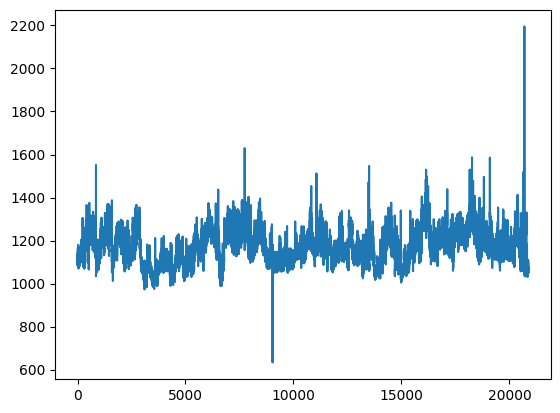

In [136]:
df['canonical_memory_usage'].plot.line()

plt.show()

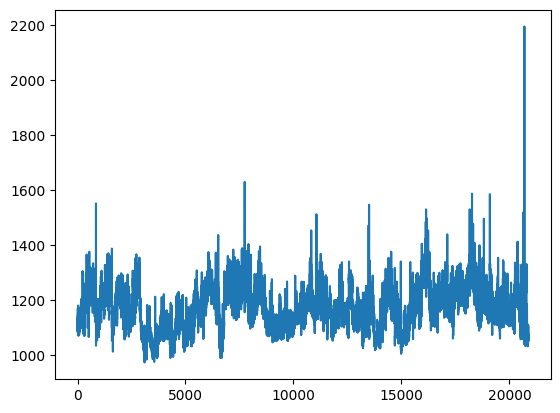

In [137]:
# Step 2: Replace Flagged canonical_memory_usages with NaN
df.loc[df['canonical_memory_usage'] < 900, 'canonical_memory_usage'] = np.nan

# Step 3: Interpolate the NaN canonical_memory_usages
df['canonical_memory_usage'] = df['canonical_memory_usage'].interpolate(method='cubicspline')

df['canonical_memory_usage'].plot.line()

plt.show()

In [138]:
# Calculate the sizes for each split
train_size = int(0.8 * len(df))
test_size = len(df) - train_size

# **Preprocessing**

In [139]:
cpu_max = df['mean_CPU_usage_rate'].max()
memory_max = df['canonical_memory_usage'].max()

# cpu_max = 4000
# memory_max = 3000

print(cpu_max, memory_max)

3275.2502055647037 2195.1658835744297


In [140]:
df['mean_CPU_usage_rate'] = df['mean_CPU_usage_rate'] / cpu_max
df['canonical_memory_usage'] = df['canonical_memory_usage'] / memory_max

# df['mean_CPU_usage_rate'] = df['mean_CPU_usage_rate'].clip(0, 1)
# df['canonical_memory_usage'] = df['canonical_memory_usage'].clip(0, 1)

<Axes: >

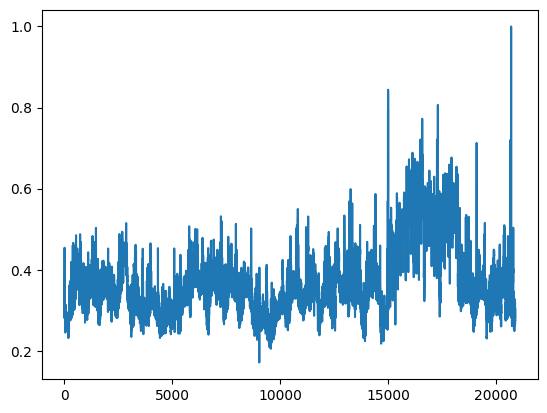

In [141]:
df['mean_CPU_usage_rate'].plot.line()

<Axes: >

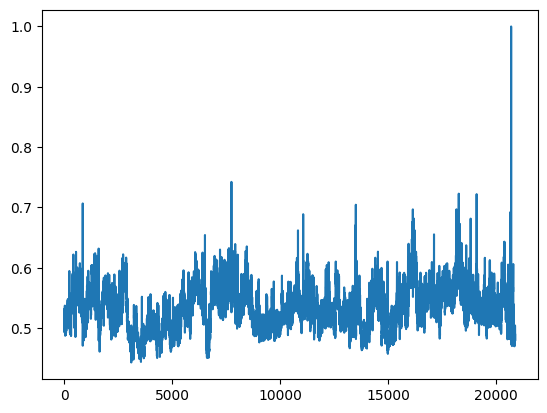

In [142]:

df['canonical_memory_usage'].plot.line()

### Creating Lag features for the time series data.

In [143]:
for i in range(1, lookback_window + 1):
    df[f'mean_CPU_usage_rate_-{i*2}min'] = df['mean_CPU_usage_rate'].shift(i)
    df[f'canonical_memory_usage_-{i*2}min'] = df['canonical_memory_usage'].shift(i)


df['rolling_mean_CPU_usage'] = df['mean_CPU_usage_rate'].shift(1).rolling(center=False, window=lookback_window).mean()
df['rolling_std_CPU_usage'] = df['mean_CPU_usage_rate'].shift(1).rolling(center=False, window=lookback_window).std()

df['rolling_mean_memory_usage'] = df['canonical_memory_usage'].shift(1).rolling(center=False, window=lookback_window).mean()
df['rolling_std_memory_usage'] = df['canonical_memory_usage'].shift(1).rolling(center=False, window=lookback_window).std()

df['target_mean_CPU_usage_rate'] = df['mean_CPU_usage_rate'].shift(-1)
df['target_canonical_memory_usage'] = df['canonical_memory_usage'].shift(-1)

df.dropna(inplace=True)

df.head()

,time_bins,mean_CPU_usage_rate,canonical_memory_usage,assigned_memory_usage,unmapped_page_cache_memory_usage,total_page_cache_memory_usage,mean_disk_I/O_time,mean_local_disk_space_used,cycles_per_instruction,memory_accesses_per_instruction,...,mean_CPU_usage_rate_-18min,canonical_memory_usage_-18min,mean_CPU_usage_rate_-20min,canonical_memory_usage_-20min,rolling_mean_CPU_usage,rolling_std_CPU_usage,rolling_mean_memory_usage,rolling_std_memory_usage,target_mean_CPU_usage_rate,target_canonical_memory_usage
10,1970-01-01 00:30:00,0.352756,0.505635,1400.376993,135.777351,341.036311,111.428184,5.743116,249970.099174,818.696352,...,0.291194,0.498747,0.285331,0.511160,0.318077,0.037974,0.506641,0.007583,0.334318,0.493024
11,1970-01-01 00:32:00,0.334318,0.493024,1368.691650,134.789350,339.324181,104.101183,5.699283,227644.159057,760.608429,...,0.326633,0.518259,0.291194,0.498747,0.324820,0.037497,0.506088,0.007417,0.342154,0.503935
12,1970-01-01 00:34:00,0.342154,0.503935,1397.686967,136.464899,340.870115,122.281748,5.823497,237846.302024,790.601992,...,0.290052,0.500780,0.326633,0.518259,0.329132,0.035634,0.505516,0.008223,0.399356,0.513893
13,1970-01-01 00:36:00,0.399356,0.513893,1424.054042,141.935103,346.624776,169.613989,6.311834,268013.370661,877.268579,...,0.293859,0.503943,0.290052,0.500780,0.330684,0.035850,0.504084,0.006898,0.454269,0.525228
14,1970-01-01 00:38:00,0.454269,0.525228,1444.967720,148.643874,353.741938,169.406521,5.724783,247520.037683,809.132076,...,0.297765,0.508641,0.293859,0.503943,0.341615,0.038639,0.505395,0.007426,0.357060,0.532397


In [144]:
lag_features = []

for i in range(1, lookback_window + 1):
    lag_features.append(f'mean_CPU_usage_rate_-{i*2}min')
    lag_features.append(f'canonical_memory_usage_-{i*2}min')

In [145]:
features = [
    'mean_CPU_usage_rate',
    'canonical_memory_usage',
    'rolling_std_CPU_usage',
    'rolling_std_memory_usage',
    'rolling_mean_CPU_usage',
    'rolling_mean_memory_usage',
    *lag_features,
]

target = [
    'target_mean_CPU_usage_rate',
    'target_canonical_memory_usage',
]

df = df[target + features]

In [146]:
df.head(8)

,target_mean_CPU_usage_rate,target_canonical_memory_usage,mean_CPU_usage_rate,canonical_memory_usage,rolling_std_CPU_usage,rolling_std_memory_usage,rolling_mean_CPU_usage,rolling_mean_memory_usage,mean_CPU_usage_rate_-2min,canonical_memory_usage_-2min,...,mean_CPU_usage_rate_-12min,canonical_memory_usage_-12min,mean_CPU_usage_rate_-14min,canonical_memory_usage_-14min,mean_CPU_usage_rate_-16min,canonical_memory_usage_-16min,mean_CPU_usage_rate_-18min,canonical_memory_usage_-18min,mean_CPU_usage_rate_-20min,canonical_memory_usage_-20min
10,0.334318,0.493024,0.352756,0.505635,0.037974,0.007583,0.318077,0.506641,0.366211,0.505998,...,0.293859,0.503943,0.290052,0.500780,0.326633,0.518259,0.291194,0.498747,0.285331,0.511160
11,0.342154,0.503935,0.334318,0.493024,0.037497,0.007417,0.324820,0.506088,0.352756,0.505635,...,0.297765,0.508641,0.293859,0.503943,0.290052,0.500780,0.326633,0.518259,0.291194,0.498747
12,0.399356,0.513893,0.342154,0.503935,0.035634,0.008223,0.329132,0.505516,0.334318,0.493024,...,0.285083,0.495103,0.297765,0.508641,0.293859,0.503943,0.290052,0.500780,0.326633,0.518259
13,0.454269,0.525228,0.399356,0.513893,0.035850,0.006898,0.330684,0.504084,0.342154,0.503935,...,0.376510,0.517616,0.285083,0.495103,0.297765,0.508641,0.293859,0.503943,0.290052,0.500780
14,0.357060,0.532397,0.454269,0.525228,0.038639,0.007426,0.341615,0.505395,0.399356,0.513893,...,0.368136,0.506162,0.376510,0.517616,0.285083,0.495103,0.297765,0.508641,0.293859,0.503943
15,0.337610,0.510423,0.357060,0.532397,0.048619,0.009674,0.357656,0.507524,0.454269,0.525228,...,0.366211,0.505998,0.368136,0.506162,0.376510,0.517616,0.285083,0.495103,0.297765,0.508641
16,0.333196,0.518543,0.337610,0.510423,0.043889,0.012487,0.363585,0.509899,0.357060,0.532397,...,0.352756,0.505635,0.366211,0.505998,0.368136,0.506162,0.376510,0.517616,0.285083,0.495103
17,0.296986,0.507720,0.333196,0.518543,0.035858,0.011358,0.368838,0.511431,0.337610,0.510423,...,0.334318,0.493024,0.352756,0.505635,0.366211,0.505998,0.368136,0.506162,0.376510,0.517616


In [147]:
# Split the dataset
train_set = df[:train_size]
test_set = df[train_size:]

In [148]:
Y_train = train_set[target]
X_train = train_set[features]

In [149]:
Y_test = test_set[target]
X_test = test_set[features]

# **Modeling**

In [150]:
from xgboost import XGBRegressor

In [151]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

model = XGBRegressor(objective='reg:squarederror', n_jobs=-1)
param_grid = {
    'n_estimators': [350, 400, 450],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [1.0],
    'colsample_bytree': [0.8, 1.0],
}

# TimeSeriesSplit for validation
tscv = TimeSeriesSplit(n_splits=4)

# GridSearchCV
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=tscv,
    verbose=1,
    n_jobs=-1
)

# Run grid search
grid_search.fit(X_train, Y_train)

# Get best model
best_model = grid_search.best_estimator_
best_params = grid_search.best_params_
print("Best Parameters:", best_params)

Fitting 4 folds for each of 54 candidates, totalling 216 fits


Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 350, 'subsample': 1.0}


In [152]:
model = XGBRegressor(**best_params)
model.fit(X_train, Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=1.0, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=350, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [153]:
model.score(X_test, Y_test)

0.8755435943603516

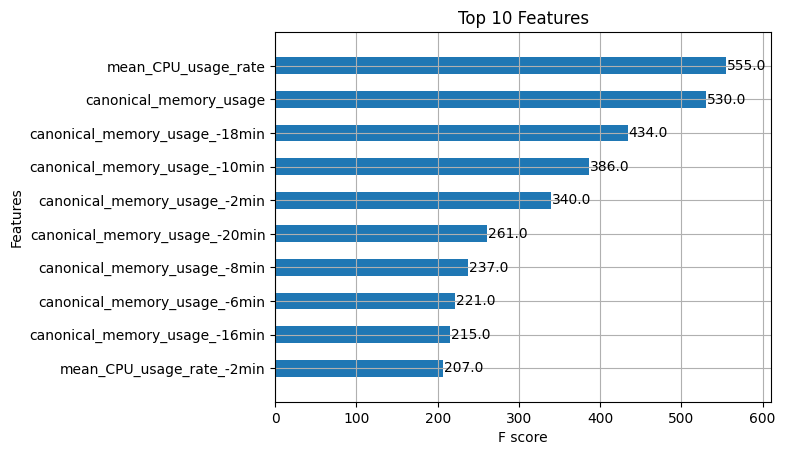

In [154]:
from xgboost import plot_importance

plot_importance(model, max_num_features=10, height=0.5, title="Top 10 Features")
plt.show()

In [155]:
y_pred = model.predict(X_test)

y_pred

array([[0.55123633, 0.5632219 ],
       [0.546736  , 0.5576868 ],
       [0.56710976, 0.56593454],
       ...,
       [0.29079333, 0.4918119 ],
       [0.2873545 , 0.48337623],
       [0.295612  , 0.49135864]], dtype=float32)


--- Variable target_mean_CPU_usage_rate ---
RMSE: 0.025932807975340904
MAE: 0.014926141043950328
MAPE: 0.036090729753380575
R2 Score: 0.9347717495458747

--- Variable target_canonical_memory_usage ---
RMSE: 0.012611420248239235
MAE: 0.006709816042010898
MAPE: 0.01206685492995755
R2 Score: 0.8163155203476721


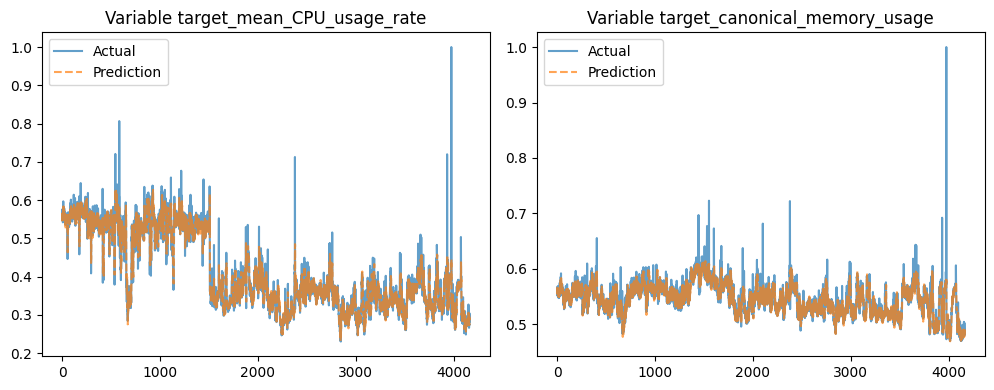

In [156]:
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

y_test = Y_test.to_numpy()

for i in range(y_test.shape[1]):
    print(f"\n--- Variable {target[i]} ---")
    print(f"RMSE: {root_mean_squared_error(y_test[:, i], y_pred[:, i])}")
    print(f"MAE: {mean_absolute_error(y_test[:, i], y_pred[:, i])}")
    print(f"MAPE: {mean_absolute_percentage_error(y_test[:, i], y_pred[:, i])}")
    print(f"R2 Score: {r2_score(y_test[:, i], y_pred[:, i])}")

# Plot each variable separately
plt.figure(figsize=(15, 4))

for i in range(y_test.shape[1]):
    plt.subplot(1, 3, i+1)
    plt.plot(y_test[:, i], label="Actual", alpha=0.7)
    plt.plot(y_pred[:, i], label="Prediction", linestyle="--", alpha=0.7)
    plt.title(f"Variable {target[i]}")
    plt.legend()

plt.tight_layout()
plt.show()

In [157]:
model.save_model('../models/best_xgboost.json')